In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Task 1: One-Sample t-Test

**Scenario:** A coffee-shop chain claims that the average wait time at their stores is 4.0 minutes. You have collected wait times (in minutes) from a random sample of 35 visits.

1. Generate (or load) the sample data. If generating, use something like:

```python
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)
```

2. State the null and alternative hypotheses in a Markdown cell.
3. Run `st.ttest_1samp(wait_times, popmean=4.0)`.
4. Report the t-statistic and p-value.
5. At α = 0.05, state whether you reject or fail to reject H₀.
6. Write a one-sentence plain-language interpretation (e.g. "There is / is not sufficient evidence that the average wait time differs from 4 minutes.").


In [6]:
np.random.seed(42)

wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)
wait_times

array([4.89605698, 4.13408284, 5.07722625, 6.12763583, 4.01901595,
       4.01903565, 6.19505538, 5.22092167, 3.73663074, 4.95107205,
       3.74389877, 3.7411243 , 4.59035473, 2.00406371, 2.2300986 ,
       3.62525496, 3.08460266, 4.6770968 , 3.21037111, 2.60523556,
       6.05877852, 4.02906844, 4.38103385, 2.59030218, 3.64674073,
       4.43310711, 2.91880771, 4.75083762, 3.57923357, 3.9499675 ,
       3.57795207, 6.52273382, 4.28380333, 3.03074689, 5.28705389])

H₀ (null): μ = 4


H₁ (alternative): μ ≠ 4 (two-tailed test)

In [11]:
t_stat, p_val = st.ttest_1samp(wait_times, popmean=4.0)

In [12]:
p_val

np.float64(0.4613582663773366)

In [13]:
t_stat

np.float64(0.7450545455494864)

At α = 0.05 level, we fail to reject the NULL Hypothesis, because our **p value > α**

There is **not sufficient** evidence that the average wait time differs from 4 minutes( p > α)

# Task 2: Independent Two-Sample t-Test

**Scenario:** An e-commerce company ran an A/B test on its checkout page. Group A (control, n = 50) saw the old design; Group B (treatment, n = 50) saw a streamlined design. The metric is order value in euros.

1. Generate (or load) data for both groups. Example:

```python
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)
```

2. State hypotheses (two-tailed: means are equal vs. not equal).
3. Before running the test, check the **equal-variance assumption**:
   - Compute the variance of each group.
   - Run Levene's test (`st.levene`). Report the result.
4. Based on the Levene result, choose the appropriate test:
   - Equal variances → `st.ttest_ind(a, b, equal_var=True)`
   - Unequal variances → `st.ttest_ind(a, b, equal_var=False)` (Welch's t-test)
5. Report the t-statistic and p-value.
6. State your decision and a plain-language interpretation.

In [15]:
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)



H₀: μₐ = μᵦ


H₁: μₐ ≠ μᵦ

In [21]:
st.levene(group_a,group_b)

LeveneResult(statistic=np.float64(0.1394706424159864), pvalue=np.float64(0.7096144854457784))

Our **p value** here( derived from Levene test) is extremely large, we can conclude that variances of each is group **is equal**

In [24]:
t_val1, p_val1 = st.ttest_ind(group_a, group_b, equal_var=True)

In [26]:
t_val1

np.float64(-2.26051641411263)

In [27]:
p_val1

np.float64(0.026001356171491255)

Here our **p value < α**( I choose significance level  α = 0.05), therefore we can conclude that there is enough evidence to reject H0(null hyphothesis). 

There is sufficient evidence to conclude that **the average order values differ between the two designs**.

# Task 3: Paired t-Test

**Scenario:** A company measures employee productivity scores before and after a new workflow tool is introduced. The same 30 employees are measured at both time points.

1. Generate (or load) paired data:

```python
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)
```

2. State hypotheses (one-tailed or two-tailed — justify your choice in a Markdown cell).
3. Compute the differences (`after - before`) and briefly inspect them (histogram or box plot).
4. Run `st.ttest_rel(after, before)`.
5. Report the t-statistic and p-value.
6. State your decision and interpretation.

In [28]:
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)

H₀: μ_d = 0


H₁: μ_d ≠ 0

(where μ_d = mean(after − before))

This is **two-tailed hypothesis**

In [50]:
diff = after - before
diff

array([ 5.06390463,  7.1103008 , 12.48396491,  1.77305942, -0.76868082,
       -1.44757215, -1.07905142,  2.61449145,  4.70575987,  4.383454  ,
        7.13591625,  3.06500946, 10.26767039,  1.67671583, 16.60084583,
        6.12833674, -1.28578778, -2.35446249,  5.41236208,  1.88268607,
        6.57000247,  5.36618812,  2.63585544, -1.23396859, -4.57423612,
        0.76742524,  7.28199397,  4.07046872, -3.22869389,  3.86590463])

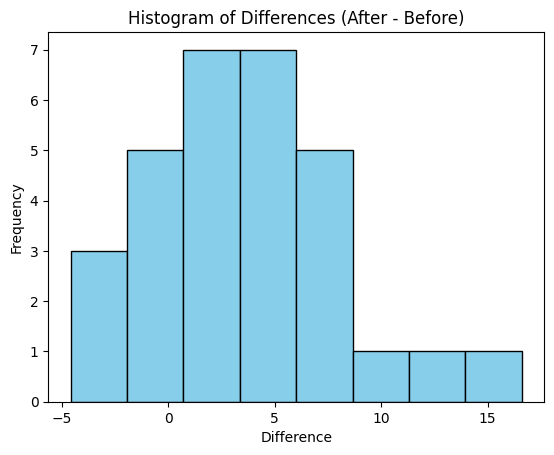

In [51]:
plt.hist(diff, bins=8, color='skyblue', edgecolor='black')
plt.title("Histogram of Differences (After - Before)")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()



In [47]:
t_val2, p_val2 = st.ttest_rel(after, before)

In [48]:
t_val2

np.float64(4.079159168339153)

In [49]:
p_val2

np.float64(0.0003225522319843033)

So our **p value(0.0003225522319843033) < α**( I choose significance level  α = 0.05), therefore we can conclude that there is enough evidence to reject H0(null hyphothesis). 

There is sufficient statistical evidence that mean productivity after the new workflow tool is significantly different from before, and based on the differences, it has increased after the tool was introduced.